# Phase 1: Project Initialization & Data Loading
 
1. Environment Setup & Data Loading

Goal: Connect Python to the dataset on Kaggle and verify the initial "DNA" of the data.


In [ ]:
#%pip install kaggle

In [ ]:
import os
import pandas as pd
import numpy as np

# Set your credentials to connect to Kaggle
try:
    from kaggle.api.kaggle_api_extended import KaggleApi
    # 2. INITIALIZE & AUTHENTICATE
    api = KaggleApi()
    api.authenticate()

    # 3. DOWNLOAD THE DATASET
    # dataset: the 'username/dataset-name' identifier from Kaggle
    # path: '.' means download into the current folder
    # unzip=True: automatically extracts the CSV files from the zip
    api.dataset_download_files('ironwolf437/laptop-price-dataset', path='.', unzip=True)

    # 4. LOAD THE DATA
    file_name = 'laptop_price - dataset.csv'
    df = pd.read_csv(file_name, encoding='latin-1') 
    print("--- SUCCESS: DATA LOADED ---")
    
    # 1. Total Rows/Columns
    print(f"Dimensions: {df.shape}")
    
    # 2. The 'DNA' Check (Data Types)
    print("\nColumn Info:")
    print(df.dtypes)
    
    # 3. See the first 5 rows
    print("\nPreview:")
    print(df.head())

except Exception as e:
    print(f"Still can't find it! Error: {e}")

Dataset URL: https://www.kaggle.com/datasets/ironwolf437/laptop-price-dataset
--- SUCCESS: DATA LOADED ---
Dimensions: (1275, 15)

Column Info:
Company                    str
Product                    str
TypeName                   str
Inches                 float64
ScreenResolution           str
CPU_Company                str
CPU_Type                   str
CPU_Frequency (GHz)    float64
RAM (GB)                 int64
Memory                     str
GPU_Company                str
GPU_Type                   str
OpSys                      str
Weight (kg)            float64
Price (Euro)           float64
dtype: object

Preview:
  Company      Product   TypeName  Inches                    ScreenResolution  \
0   Apple  MacBook Pro  Ultrabook    13.3  IPS Panel Retina Display 2560x1600   
1   Apple  Macbook Air  Ultrabook    13.3                            1440x900   
2      HP       250 G6   Notebook    15.6                   Full HD 1920x1080   
3   Apple  MacBook Pro  Ultrabook    15.4  

# Phase 2: Data Investigation (The 'DNA' Check)

2. Data Investigation & Type Verification

Goal: Check for missing values and ensure columns like RAM and Weight are numeric.

In [3]:
#Check column name and datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   str    
 1   Product              1275 non-null   str    
 2   TypeName             1275 non-null   str    
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   str    
 5   CPU_Company          1275 non-null   str    
 6   CPU_Type             1275 non-null   str    
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   str    
 10  GPU_Company          1275 non-null   str    
 11  GPU_Type             1275 non-null   str    
 12  OpSys                1275 non-null   str    
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float64
dtypes: float64(4), int64(1), str(10)
memory usage: 28

In [4]:
#Descriptive Statistics
df.describe()

,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,2.302980,8.440784,2.040525,1134.969059
std,1.429470,0.503846,5.097809,0.669196,700.752504
min,10.100000,0.900000,2.000000,0.690000,174.000000
25%,14.000000,2.000000,4.000000,1.500000,609.000000
50%,15.600000,2.500000,8.000000,2.040000,989.000000
75%,15.600000,2.700000,8.000000,2.310000,1496.500000
max,18.400000,3.600000,64.000000,4.700000,6099.000000


In [5]:
#View the first 10 rows
df.head(10)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.00
6,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.2,16,256GB Flash Storage,Intel,Iris Pro Graphics,Mac OS X,2.04,2139.97
7,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70
8,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,512GB SSD,Nvidia,GeForce MX150,Windows 10,1.30,1495.00
9,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,256GB SSD,Intel,UHD Graphics 620,Windows 10,1.60,770.00


In [6]:
#Count Missing values
df.isnull().sum()

Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
dtype: int64

 # Phase 3: Feature Impact Analysis (Grouping)

3. Exploratory Data Analysis: Grouped Insights

Goal: Identify which Brands and Hardware Specs (RAM) drive the highest prices.

Brand Power Analysis

In [7]:
#Average Price per brand
brand_stats=df.groupby('Company')['Price (Euro)'].mean().sort_values(ascending=False)
print("Average Price by Company")
print(brand_stats)

Average Price by Company
Company
Razer        3346.142857
LG           2099.000000
MSI          1728.908148
Google       1677.666667
Microsoft    1612.308333
Apple        1564.198571
Huawei       1424.000000
Samsung      1413.444444
Toshiba      1267.812500
Dell         1199.225120
Xiaomi       1133.462500
Asus         1123.829737
Lenovo       1093.862215
HP           1080.314664
Fujitsu       729.000000
Acer          633.464455
Chuwi         314.296667
Mediacom      295.000000
Vero          217.425000
Name: Price (Euro), dtype: float64


The Cost of Performance (RAM)

In [8]:
#Average Price per RAM size
ram_stats=df.groupby('RAM (GB)')['Price (Euro)'].mean()
print("Average price by RAM size:")
print(ram_stats)


Average price by RAM size:
RAM (GB)
2      247.634375
4      576.109101
6      619.356571
8     1184.429413
12    1239.438400
16    1941.193081
24    2206.333333
32    3413.085882
64    3975.000000
Name: Price (Euro), dtype: float64


# The Correlation Matrix (The "Brain" of the Model)

# Phase 4: Feature Selection (Correlation)

4. Feature Selection: Correlation Analysis

Goal: Mathematically determine which features (like RAM) have the strongest impact on Price.

In [9]:
# Feature Correlation
correlation=df[['Price (Euro)', 'Weight (kg)', 'RAM (GB)']].corr()
print("Correlation Matrix :")
print(correlation)

Correlation Matrix :
              Price (Euro)  Weight (kg)  RAM (GB)
Price (Euro)      1.000000     0.211883  0.740287
Weight (kg)       0.211883     1.000000  0.389370
RAM (GB)          0.740287     0.389370  1.000000


# Phase 5: Data Visualization (Correlation & Trends)

Goal: Turn the 0.74 correlation number into a visual "story" using a Regression Plot and a Heatmap.

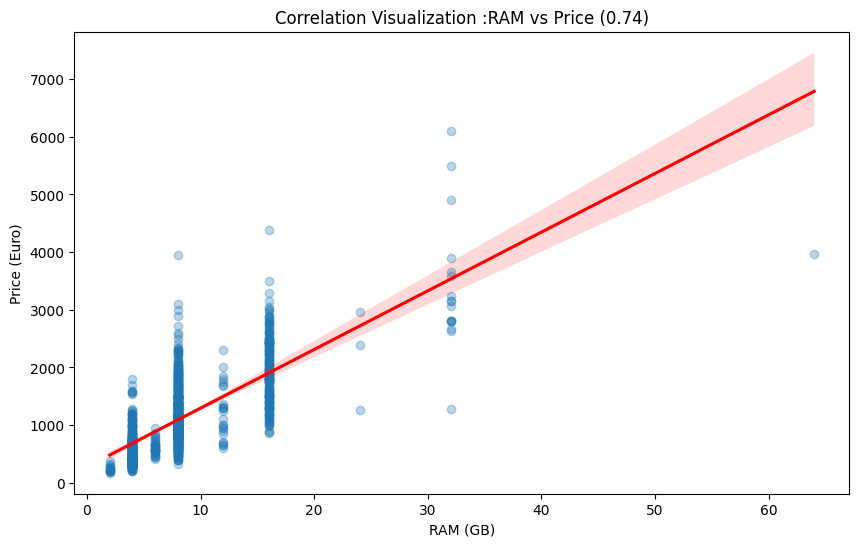

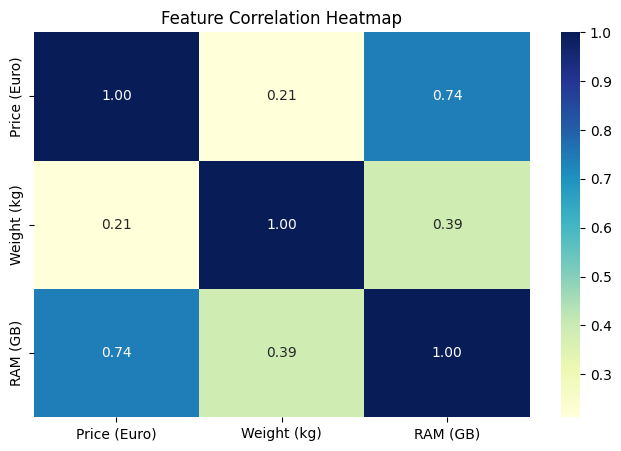

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Regression Plot : The ''Line of Best Fit''
# This Physically  draws the  0.74 correlation line
plt.figure(figsize =(10,6))
sns.regplot(x="RAM (GB)", y="Price (Euro)", data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Correlation Visualization :RAM vs Price (0.74)')
plt.show()

# 2.Correlation Heatmap: The "Impact Grid"
# This shows all relationships in a color-coded heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df[['Price (Euro)', 'Weight (kg)', 'RAM (GB)']].corr(),annot=True, cmap='YlGnBu',fmt=".2f" )
plt.title('Feature Correlation Heatmap')
plt.show()

# Phase 6: Data Filtering (The "Outlier" Hunt)

Goal: Use logic to find the "expensive anomalies"—like that one 8GB laptop that costs as much as a 32GB one.

In [11]:
#Phase 6: Finding the most expensive 8GB laptops
expensive_8gb=df[df['RAM (GB)']==8].sort_values(by='Price (Euro)',ascending=False)

# Show the top 5
print("Top 5 Most Expensive 8GB Laptops:")
expensive_8gb[['Company','Product','TypeName','CPU_Company','CPU_Type','RAM (GB)','Price (Euro)']].head()

Top 5 Most Expensive 8GB Laptops:


,Company,Product,TypeName,CPU_Company,CPU_Type,RAM (GB),Price (Euro)
1136,HP,ZBook 17,Workstation,Intel,Core i7 6700HQ,8,3949.4
911,HP,Elitebook Folio,Ultrabook,Intel,Core M 6Y75,8,3100.0
563,Lenovo,Thinkpad P71,Notebook,Intel,Core i7 7700HQ,8,2999.0
1103,HP,ZBook 17,Workstation,Intel,Core i7 6700HQ,8,2899.0
398,Dell,Precision M5520,Workstation,Intel,Core i7 7700HQ,8,2712.0


In [12]:
# Check every unique version of RAM in your data
print("Unique values in RAM column:")
print(df['RAM (GB)'].unique())

# See how many of each exist
print("\nFrequency of each value:")
print(df['RAM (GB)'].value_counts())

print("\n--- CPU Sample (The real mess) ---")
print(df['CPU_Type'].head(10))

Unique values in RAM column:
[ 8 16  4  2 12  6 32 24 64]

Frequency of each value:
RAM (GB)
8     613
4     367
16    198
6      35
12     25
32     17
2      16
24      3
64      1
Name: count, dtype: int64

--- CPU Sample (The real mess) ---
0           Core i5
1           Core i5
2     Core i5 7200U
3           Core i7
4           Core i5
5    A9-Series 9420
6           Core i7
7           Core i5
8     Core i7 8550U
9     Core i5 8250U
Name: CPU_Type, dtype: str


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   str    
 1   Product              1275 non-null   str    
 2   TypeName             1275 non-null   str    
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   str    
 5   CPU_Company          1275 non-null   str    
 6   CPU_Type             1275 non-null   str    
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   str    
 10  GPU_Company          1275 non-null   str    
 11  GPU_Type             1275 non-null   str    
 12  OpSys                1275 non-null   str    
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float64
dtypes: float64(4), int64(1), str(10)
memory usage: 28

# Phase 7: Feature Engineering (The Surgery)

In this phase, we are going to perform three major "Extractions" to turn messy text into clean numbers.

# Step 1: Extracting Touchscreen and IPS

An AI cannot "read" the words in ScreenResolution. We need to create Binary Columns (1s and 0s).

The Screen Resolution "Gold Mine"

The ScreenResolution column has too much noise. We need to extract the Touchscreen and IPS Panel features as 1s and 0s.

In [14]:
# 1.Create Binay Columns (1 = Yes, 0 = No)
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
df['Ips'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

# 2. Check the Price Impact
print("Avg Price for IPS Panel:")
print(df.groupby('Ips')['Price (Euro)'].mean())

print("\n Avg Price for Touchscreen:")
print(df.groupby('Touchscreen')['Price (Euro)'].mean())

# Check the results
print("Total Touchscreen Laptops:", df['Touchscreen'].sum())
print("Total IPS Panel Laptops:", df['Ips'].sum())

# 3. Check if it worked
df[['ScreenResolution', 'Touchscreen', 'Ips']].head(10)

Avg Price for IPS Panel:
Ips
0    1025.440882
1    1416.612941
Name: Price (Euro), dtype: float64

 Avg Price for Touchscreen:
Touchscreen
0    1079.944204
1    1453.118085
Name: Price (Euro), dtype: float64
Total Touchscreen Laptops: 188
Total IPS Panel Laptops: 357


,ScreenResolution,Touchscreen,Ips
0,IPS Panel Retina Display 2560x1600,0,1
1,1440x900,0,0
2,Full HD 1920x1080,0,0
3,IPS Panel Retina Display 2880x1800,0,1
4,IPS Panel Retina Display 2560x1600,0,1
5,1366x768,0,0
6,IPS Panel Retina Display 2880x1800,0,1
7,1440x900,0,0
8,Full HD 1920x1080,0,0
9,IPS Panel Full HD 1920x1080,0,1


# Step 2: Extracting Resolution (X and Y Pixels)

To find the screen's sharpness, we need to pull the numbers (like 1920 and 1080) out of the text.


In [15]:
# 1. Split the string at 'x'
new = df['ScreenResolution'].str.split('x',n=1,expand =True)
new.head()

# 2.Extract X=resolution (using regex to find the digits right before the 'x')
df['X_res'] = new[0].str.extract(r'(\d+)').astype(int)

# 3.Extract Y-resolution ( the part after the 'x')
df['Y_res'] = new[1].str.extract(r'(\d+)').astype('int')

# View the clean numbers
df[['ScreenResolution','X_res','Y_res']].head()
# new.head()

,ScreenResolution,X_res,Y_res
0,IPS Panel Retina Display 2560x1600,2560,1600
1,1440x900,1440,900
2,Full HD 1920x1080,1920,1080
3,IPS Panel Retina Display 2880x1800,2880,1800
4,IPS Panel Retina Display 2560x1600,2560,1600


# Step 3: Calculating PPI (The "Golden" Feature)

Instead of using two columns (X and Y), we combine them with the Inches column to get PPI (Pixels Per Inch). This is a single number that tells the AI exactly how sharp the screen is.


In [16]:
# Calculate PPI
# Formula : sqrt(X^2 +Y^2) /Inches

df['ppi']=(((df['X_res']**2)+ (df['Y_res']**2))**0.5 / df['Inches']).astype(float)

# Check correlation again - see if PPI impacts price!
print ("Correlation with Price:")

print(df.corr(numeric_only=True)['Price (Euro)'].sort_values(ascending=False))

# Now drop the messy original and intermediate columns to keep it clean
df.drop(columns =['ScreenResolution','X_res','Y_res','Inches'], inplace=True)
#df.head()

Correlation with Price:
Price (Euro)           1.000000
RAM (GB)               0.740287
Y_res                  0.548529
CPU_Frequency (GHz)    0.428847
ppi                    0.343161
Ips                    0.250737
Weight (kg)            0.211883
Touchscreen            0.188886
X_res                  0.072893
Inches                 0.066608
Name: Price (Euro), dtype: float64


# Phase 8 : Feature Engineering - CPU Simplifier (Pre-Surgery)

CPU Feature Engineering

In [17]:
# 1.Create a simplified CPU Column
df['CPU Name']=df['CPU_Type'].apply(lambda x:" ".join(x.split()[0:3]))

# 2.Create the unique names we just created
print("Simplified CPU Name")
print(df['CPU Name'].value_counts().head(10))

Simplified CPU Name
CPU Name
Core i5 7200U        193
Core i7 7700HQ       147
Core i7 7500U        133
Core i3 6006U         81
Core i7 8550U         73
Core i5 8250U         72
Celeron Dual Core     70
Core i5 6200U         68
Core i7 6500U         43
Core i7 6700HQ        41
Name: count, dtype: int64


In [18]:
print(df['CPU_Type'].value_counts())

CPU_Type
Core i5 7200U     193
Core i7 7700HQ    147
Core i7 7500U     133
Core i3 6006U      81
Core i7 8550U      73
                 ... 
Core M 6Y54         1
Cortex A72&A53      1
E-Series 9000       1
Core M 6Y30         1
A9-Series 9410      1
Name: count, Length: 93, dtype: int64


The CPU Simplifier (Surgery to clean the CPU Type)

As you noticed, your CPU names are long (e.g., "Core i5 7200U"). We need to bucket them so the AI doesn't get confused by minor model differences.

In [19]:
# 1.Extract the first two words (e.g., 'Core i5')

df['CPU Type'] =df['CPU_Type'].apply(lambda x: " ".join(x.split()[0:2]))

# 2. Define the 'Surgery' function
def categorize_cpu(text):
    # High-end Intel
    if text == 'Core i7' or text == 'Core i5' or text == 'Core i3':
        return text
    # Budget/Low-power Intel (Including your Core M)
    elif 'Celeron' in text or 'Pentium' in text or 'Core M' in text:
        return 'Budget Intel'
    # AMD Processors (Including your A9-Series, Ryzen, etc.)
    elif 'AMD' in text or 'A9-Series' in text or 'A6-Series' in text or 'Ryzen' in text:
        return 'AMD'
    else:
        return 'Other'
    
# 3.Apply the function
df ['Cpu_Type'] = df ['CPU Type'].apply(categorize_cpu)

# 4.Cleanup : Drop the temporary columns to keep it professional
# (Wait to run the drop until you've verified the counts below!)
print("Final CPU Brand Counts:")
print(df['Cpu_Type'].value_counts())
#df.head(20)



Final CPU Brand Counts:
Cpu_Type
Core i7         515
Core i5         423
Core i3         134
Budget Intel    125
Other            48
AMD              30
Name: count, dtype: int64


In [20]:
# 4. Cleanup: Remove the original messy 'CPY Type' and the temporary column
df.drop(columns=['CPU Type', 'CPU Name'], inplace=True)

In [21]:
# 5. Check the result
print("Final CPU Brand Counts:")
print(df['Cpu_Type'].value_counts())
#df.head(20)

Final CPU Brand Counts:
Cpu_Type
Core i7         515
Core i5         423
Core i3         134
Budget Intel    125
Other            48
AMD              30
Name: count, dtype: int64


In [22]:
df.corr(numeric_only=True)['Price (Euro)'].sort_values(ascending=False)

Price (Euro)           1.000000
RAM (GB)               0.740287
CPU_Frequency (GHz)    0.428847
ppi                    0.343161
Ips                    0.250737
Weight (kg)            0.211883
Touchscreen            0.188886
Name: Price (Euro), dtype: float64

# Phase 9: Memory & Storage Engineering

In this phase, we transform the text-heavy Memory column into numerical values that represent the total capacity of each storage type.

Step 1: Clean and Standardize Units

We remove the "GB" and convert "TB" to "1000" so all numbers are in the same unit.

In [23]:
df.head()

,Company,Product,TypeName,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,Cpu_Type
0,Apple,MacBook Pro,Ultrabook,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.983005,Core i5
1,Apple,Macbook Air,Ultrabook,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0,127.677940,Core i5
2,HP,250 G6,Notebook,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0,141.211998,Core i5
3,Apple,MacBook Pro,Ultrabook,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1,220.534624,Core i7
4,Apple,MacBook Pro,Ultrabook,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1,226.983005,Core i5


In [24]:
# Convert to string and remove.0 , GB , and Convert TB to 000
df['Memory'] = df['Memory'].astype(str).replace(r'\.0','',regex=True)
df['Memory'] = df['Memory'].str.replace('GB','')
df['Memory'] = df['Memory'].str.replace('TB','000')

Step 2: Split Multi-Drive Laptops

We split the column into two parts to catch laptops that have both an SSD and an HDD.

In [25]:
# Split by the '+' sign
new =df['Memory'].str.split("+",n = 1, expand = True)

df['first'] = new[0].str.strip()
df['second'] = new[1].fillna("0").str.strip()

Step 3: Extract Numeric Values for each Hardware Type

We create flags (0 or 1) to identify the storage type and then multiply by the capacity.

In [26]:
# Logic to separate SSD, HDD, Flash, and Hybrid
df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer1Flash_Storage"] = df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

# Extract only the digits
df['first'] = df['first'].str.extract(r'(\d+)').astype(int)

# Repeat for the second drive slot
df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['second'] = df['second'].str.extract(r'(\d+)').astype(int)

Step 4: Final Calculation and Cleanup

We calculate the final total for the two most common types (SSD/HDD) and drop the messy helper columns.


In [27]:
# Calculate totals
df["HDD"]=(df["first"]*df["Layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["second"]*df["Layer2SSD"])

# Drop columns we no longer need
#df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid','Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid','Layer2Flash_Storage', 'Memory'], inplace=True)
df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid','Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid','Layer2Flash_Storage', 'Memory'], inplace=True)

In [28]:
df.head()

,Company,Product,TypeName,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,Cpu_Type,HDD,SSD
0,Apple,MacBook Pro,Ultrabook,Intel,Core i5,2.3,8,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.983005,Core i5,0,128
1,Apple,Macbook Air,Ultrabook,Intel,Core i5,1.8,8,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0,127.677940,Core i5,0,0
2,HP,250 G6,Notebook,Intel,Core i5 7200U,2.5,8,Intel,HD Graphics 620,No OS,1.86,575.00,0,0,141.211998,Core i5,0,256
3,Apple,MacBook Pro,Ultrabook,Intel,Core i7,2.7,16,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1,220.534624,Core i7,0,512
4,Apple,MacBook Pro,Ultrabook,Intel,Core i5,3.1,8,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1,226.983005,Core i5,0,256


# Phase 10 : Refining the GPU Column

Since the brand name is already isolated, we just need to ensure the data is "clean" for the model.

Step 1: Check for Rare Brands

In the Kaggle dataset, there is often one or two entries for ARM or other niche brands. In Machine Learning, categories with very few entries can cause errors during the "Train-Test Split" phase later.

In [29]:
df['GPU_Company'].unique()
df['GPU_Company'].value_counts()

GPU_Company
Intel     704
Nvidia    396
AMD       174
ARM         1
Name: count, dtype: int64

Step 2: Filter and Drop

If you see ARM or any brand with only 1 or 2 laptops, we should remove them to keep the model stable. If you only see Intel, AMD, and Nvidia, you can just drop the original messy Gpu column (if it's still there).


In [30]:
# Only keep rows where the brand is not 'ARM' (if it exists)
df = df[df['GPU_Company'] != 'ARM']
    
df['GPU_Company'].value_counts()

GPU_Company
Intel     704
Nvidia    396
AMD       174
Name: count, dtype: int64

In [31]:
df['OpSys'].value_counts()

OpSys
Windows 10      1048
No OS             66
Linux             58
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

# Phase 11: OS Category "Bucketing"

The OpSys column is too messy (Windows 10, Windows 7, macOS, etc.). We need to group them into: Windows, Mac, and Others/Linux.

In [32]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'MAC OS X':
        return 'Mac'
    else:
        return 'Others/No OS/Linus'
    
df['os'] = df['OpSys'].apply(cat_os)

# Drop the old messy OpSys column
df.drop(columns=['OpSys'], inplace= True)

In [33]:
df.head()

,Company,Product,TypeName,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),GPU_Company,GPU_Type,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,Cpu_Type,HDD,SSD,os
0,Apple,MacBook Pro,Ultrabook,Intel,Core i5,2.3,8,Intel,Iris Plus Graphics 640,1.37,1339.69,0,1,226.983005,Core i5,0,128,Mac
1,Apple,Macbook Air,Ultrabook,Intel,Core i5,1.8,8,Intel,HD Graphics 6000,1.34,898.94,0,0,127.677940,Core i5,0,0,Mac
2,HP,250 G6,Notebook,Intel,Core i5 7200U,2.5,8,Intel,HD Graphics 620,1.86,575.00,0,0,141.211998,Core i5,0,256,Others/No OS/Linus
3,Apple,MacBook Pro,Ultrabook,Intel,Core i7,2.7,16,AMD,Radeon Pro 455,1.83,2537.45,0,1,220.534624,Core i7,0,512,Mac
4,Apple,MacBook Pro,Ultrabook,Intel,Core i5,3.1,8,Intel,Iris Plus Graphics 650,1.37,1803.60,0,1,226.983005,Core i5,0,256,Mac


In [34]:
# 1. Drop Product and any other messy lingering columns
cols_to_drop = ['Product'] 
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

# Final cleanup of any lingering raw text columns
lingering = ['ScreenResolution', 'CPU_Type', 'Memory', 'Gpu', 'OpSys']
df.drop(columns=[col for col in lingering if col in df.columns], inplace=True)


# Exploratory Data Analysis (EDA)

# Phase 12: Price Distribution & Correlation

Before we look at specific features, we need to understand our Target Variable: the Price.

Step 1: Check the Price Distribution

We want to see if the prices are "normally distributed" or if they are skewed (e.g., many cheap laptops and a few very expensive ones).

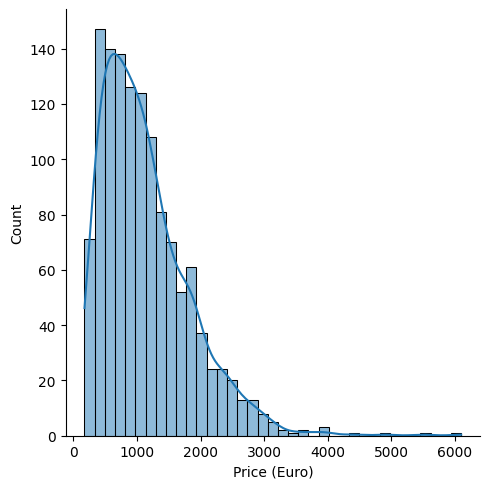

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# See the disttribution of the Price , Modern way to see Price Distribution
sns.displot(df['Price (Euro)'], kde=True)
plt.show()

Step 2: Heatmap of Correlations

Now, let’s see which of our new features (SSD, HDD, RAM) actually matters the most.

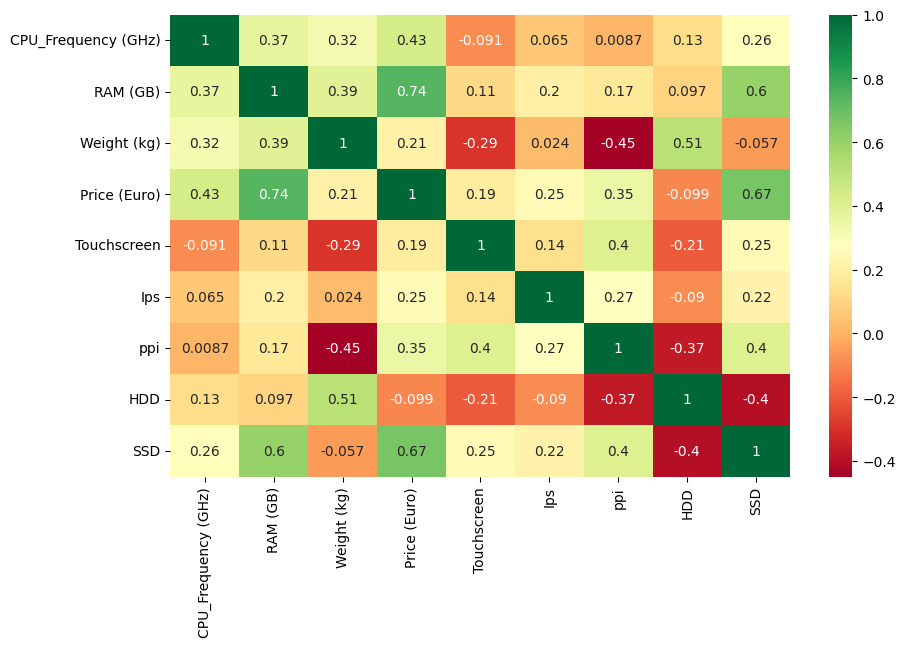

In [36]:
# Visualize how features relate to each other and the Price
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn')
plt.show()

If the heatmap is showing a high correlation for RAM (0.74) and SSD (0.67), it means the feature engineering in Phase 9 was successful. we’ve successfully translated "128GB SSD + 1TB HDD" into numbers the computer can actually rank.

# Phase 13: Categorical Visualizations

Now we look at the columns we didn't include in the heatmap (the strings). Since we can't do correlation math on "Apple" vs "Dell," we use Bar Plots to see the average price per category.
Step 1: Which Brand is the most expensive?
This helps us see if the Company name is a strong predictor of price.

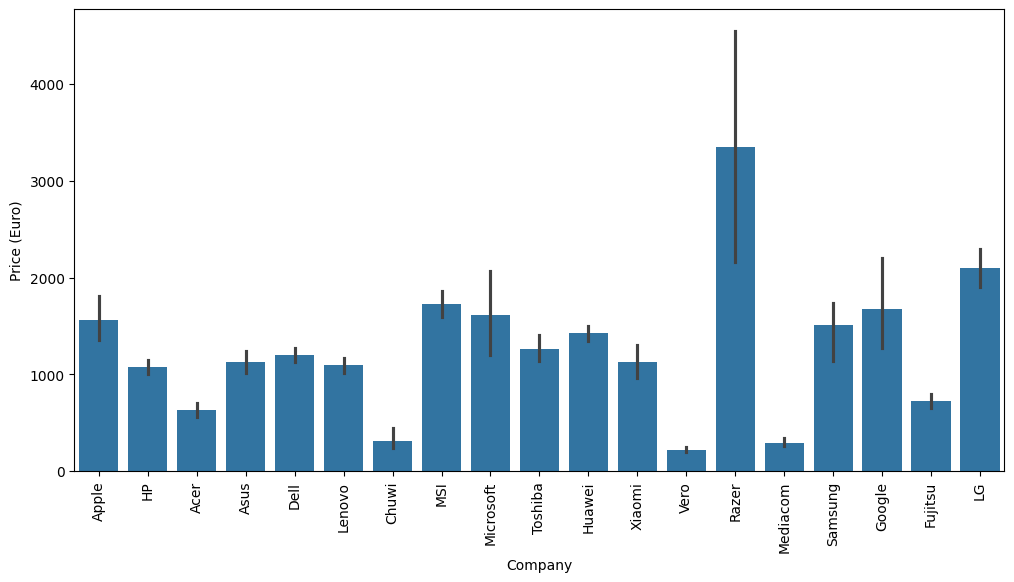

In [37]:
# Plot average price for each laptop brand
plt.figure(figsize =(12,6))
sns.barplot(x=df['Company'], y=df['Price (Euro)'])
plt.xticks(rotation ='vertical')
plt.show()

Step 2: Does the "TypeName" matter?

We want to see if "Workstations" or "Gaming" laptops are significantly more expensive than "Notebooks."

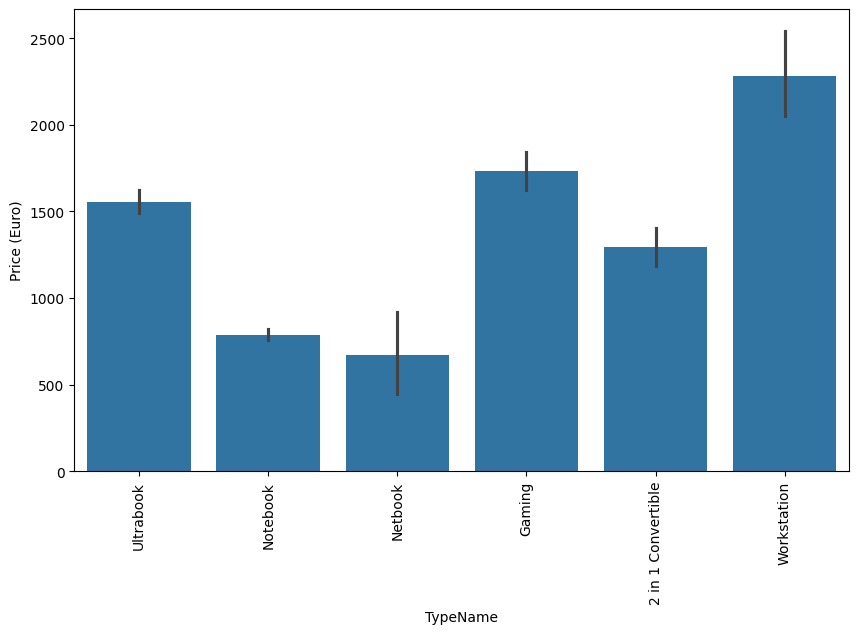

In [38]:
# Plot average price for each type of Laptop
plt.figure(figsize=(10,6))
sns.barplot(x=df['TypeName'], y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

# Phase 14: Visualizing the Engineered Features

We'll check the features we created to see if they follow a logical price trend, now we look at CPU, GPU and OS vs Price separately.

Step 1: CPU Brand vs Price

We want to see if the "Intel Core i7" or "Ryzen 7" categories we cleaned earlier actually command higher prices.

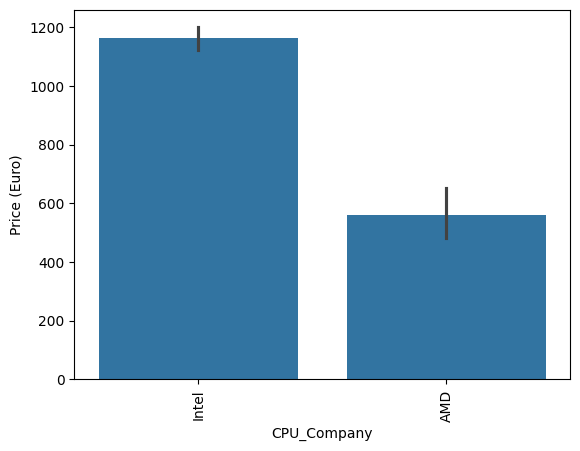

In [39]:
# Check how CPU Brand affects the price
sns.barplot(x=df['CPU_Company'], y=df['Price (Euro)'])
plt.xticks(rotation ='vertical')
plt.show()

Step 2: GPU Brand vs Price

Let's see if having an Nvidia GPU (common in gaming laptops) correlates with a higher price compared to Intel (often integrated graphics).

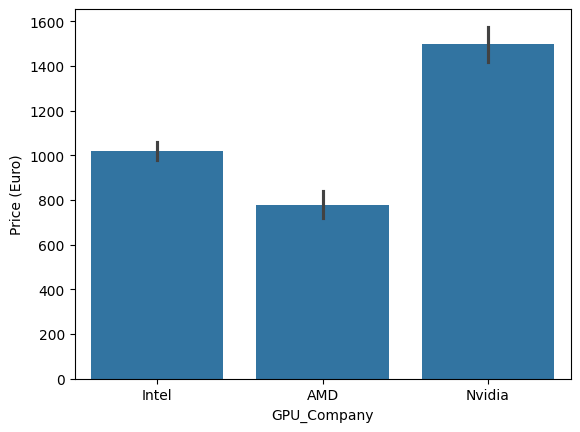

In [40]:
# Check how GPU Company affects the price
sns.barplot(x=df['GPU_Company'], y=df['Price (Euro)'])
plt.show()

Step 3: Operating System vs Price

Finally, let's see how our "Bucketed" OS categories (Mac, Windows, Others) compare.


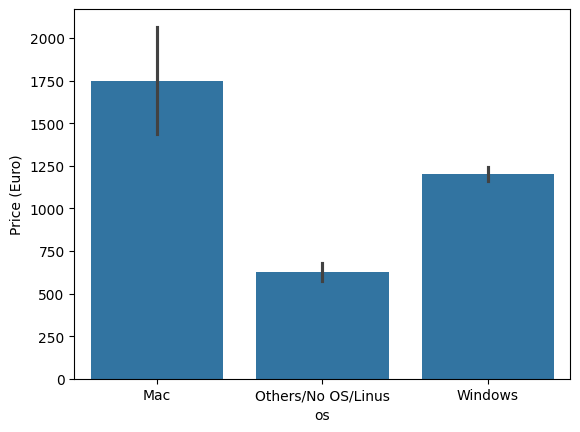

In [41]:
# Check how the OS affects the price
sns.barplot(x=df['os'], y=df['Price (Euro)'])
plt.show()

Workstations and Gaming laptops are expensive because they house the high-end CPUs and GPUs cleaned earlier, while Ultrabooks command a premium for their portability.

# Phase 15: The Final Visual Check (RAM & Screen)

Step 1: RAM vs Price

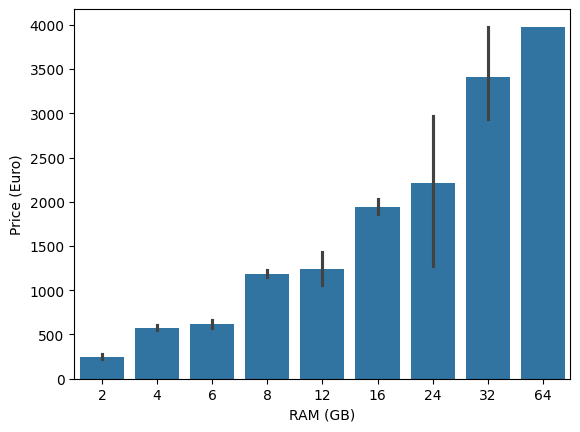

In [42]:
# A scatter plot or bar plot for RAM
sns.barplot(x=df['RAM (GB)'], y=df['Price (Euro)'])
plt.show()

Step 2: Touchscreen vs Price

Since we engineered the Touchscreen column from the screen resolution earlier, let's see if it actually adds value.

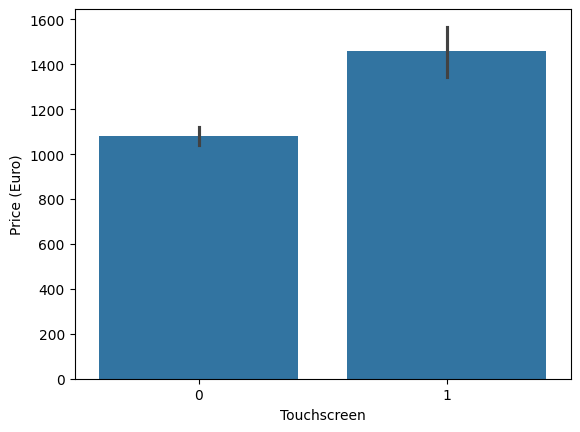

In [43]:
# Comparison of Touchscreen vs Non-Touchscreen
sns.barplot(x=df['Touchscreen'], y=df['Price (Euro)'])
plt.show()

Because computers only understand numbers, we have to convert our remaining text (like "Razer" or "Gaming") into a format the math can use.

# Phase 16: Handling Skewness (Log Transformation)

displot of Price - It had a long tail to the right because of those expensive Razer and Workstation laptops. This "skewness" makes it hard for the model to predict accurately. We fix this by using a Log Transformation on the Price.

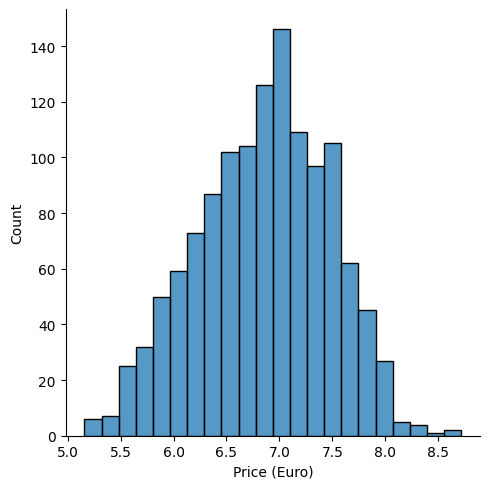

In [44]:
# Apply Log Transformation to the target variable
sns.displot(np.log(df['Price (Euro)']))
plt.show()

# Phase 17: The Train-Test Split

We need to set aside some data to "test" the model later. If we show the model all the data now, it would be like giving a student the answer key before the exam.

We split the data so the model can learn from one set (80%) and be tested on a separate "unseen" set (20%). This ensures it isn't just memorizing answers.

So here we split the questions( variables like Cpu company, RAM, GPU, Brand etc) and answers (The price - target variable) . Its more like giving the machine a set of questions so it understands the pattern behind and cross checks the answers and makes itself a math formula to guess the price.
(Creating itself it's own notes and then answering the question given.)

In [45]:
from sklearn.model_selection import train_test_split

# Separate the features (X) from the target (y)
# We use np.Log on y to match our bell curve
# X is our features (everything but price)
# y is our answer (the Log of the price)
X=df.drop(columns = ['Price (Euro)'])
y=np.log(df['Price (Euro)'])

# SPlit: 80% for training, 20% for testing
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.15,random_state=2)
X_train.head() # Run this to verify Price is gone


,Company,TypeName,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,GPU_Type,Weight (kg),Touchscreen,Ips,ppi,Cpu_Type,HDD,SSD,os
21,Lenovo,Gaming,Intel,2.5,8,Nvidia,GeForce GTX 1050,2.50,0,1,141.211998,Core i5,1000,128,Windows
790,Asus,Gaming,Intel,2.8,8,Nvidia,GeForce GTX1060,2.24,0,0,141.211998,Core i7,1000,128,Windows
273,Lenovo,2 in 1 Convertible,Intel,2.6,16,Intel,HD Graphics 520,1.36,1,0,209.800683,Core i7,0,512,Windows
397,Lenovo,Notebook,Intel,2.5,8,Intel,HD Graphics 620,1.90,0,1,157.350512,Core i5,0,256,Windows
921,HP,Ultrabook,Intel,2.5,8,AMD,Radeon R7 M365X,1.84,0,0,141.211998,Core i7,0,256,Windows


# Phase 18: Building the Machine Learning Pipeline

This is the "brain" of the project. It tells the computer: "First, convert the text columns to numbers (One-Hot Encoding), then apply Linear Regression math."

Important: Look at X_train.head() and find the index numbers (0, 1, 2, etc.) of your text columns (Company, TypeName, CPU, GPU, OS). Update the list below if yours are different.

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Step 1: Transformer to turn text into numbers
#[0,1,7,10,11] are the usual indices for text columns
# Step 1: Identify your categorical column indices
# Example: [0, 1, 7, 10, 11] usually covers Brand, Type, CPU, GPU, and OS

# Automatically find all text columns
categorical_features = X_train.select_dtypes(include=['object', 'string', 'str']).columns.tolist()

print("Encoding these columns:", categorical_features)

step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'),categorical_features)], remainder='passthrough')

# Step 2: The Algorithm
step2= LinearRegression()

# Create the Pipeline
pipe = Pipeline([('step1',step1),('step2',step2)])

# TRAIN THE MODEL (The Learning Phase)
pipe.fit(X_train, y_train)
print("✅ Success! Model is trained.")

Encoding these columns: ['Company', 'TypeName', 'CPU_Company', 'GPU_Company', 'GPU_Type', 'Cpu_Type', 'os']
✅ Success! Model is trained.


In [47]:
df.info()

<class 'pandas.DataFrame'>
Index: 1274 entries, 0 to 1274
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1274 non-null   str    
 1   TypeName             1274 non-null   str    
 2   CPU_Company          1274 non-null   str    
 3   CPU_Frequency (GHz)  1274 non-null   float64
 4   RAM (GB)             1274 non-null   int64  
 5   GPU_Company          1274 non-null   str    
 6   GPU_Type             1274 non-null   str    
 7   Weight (kg)          1274 non-null   float64
 8   Price (Euro)         1274 non-null   float64
 9   Touchscreen          1274 non-null   int64  
 10  Ips                  1274 non-null   int64  
 11  ppi                  1274 non-null   float64
 12  Cpu_Type             1274 non-null   str    
 13  HDD                  1274 non-null   int64  
 14  SSD                  1274 non-null   int64  
 15  os                   1274 non-null   str    
dtypes: f

In [48]:
# See exactly what columns your model is currently using
print("Current Columns:", df.columns.tolist())

Current Columns: ['Company', 'TypeName', 'CPU_Company', 'CPU_Frequency (GHz)', 'RAM (GB)', 'GPU_Company', 'GPU_Type', 'Weight (kg)', 'Price (Euro)', 'Touchscreen', 'Ips', 'ppi', 'Cpu_Type', 'HDD', 'SSD', 'os']


# Phase 19: Model Evaluation (The Exam)

What it is: We give the model the "Test Set" (laptops it has never seen) and ask it to guess the prices. Then we compare those guesses to the actual prices.

In [49]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.metrics import r2_score, mean_absolute_error

# 1. Get predictions (in log form)
y_pred=pipe.predict(X_test)

# 2.Compare predictions to actual values
print('R2 score:', r2_score(y_test, y_pred))

# We use np.exp because we want the error in Euros , not logs!
print('MAE:', mean_absolute_error(np.exp(y_test), np.exp(y_pred)))

R2 score: 0.8504762998035281
MAE: 196.8942934838619


* Significance:
* R2 Score: Usually between 0 and 1. If you get 0.80, it means your model is 80% accurate at explaining price variations.
* MAE (Mean Absolute Error): This is the average amount the model is "off" by. If it says 200, your model is typically within €200 of the real price.


# Phase 20: Exporting the Model (The "Save Game")

What it is: Right now, the model lives in your laptop's RAM. If you close VS Code, the "weights" it learned are gone. We use Pickle to save the model and the dataframe as files on your drive.

In [50]:
import pickle

# We save the dataframe to use for dropdown menus in our web app later
pickle.dump(df,open('df.pkl','wb'))

# We save the 'pip' ( which contains the encoder and the Model)
pickle.dump(pipe,open('pipe.pkl','wb'))



* Significance: This creates two files (df.pkl and pipe.pkl) in your project folder. These are tiny files that hold all the "knowledge" your model gained. You will need these for Day 7 to build the website.

------------------------------
# Phase 21: Testing with Custom Input
What it is: This is the fun part! You manually type in specs of a laptop to see what price the model predicts.

Here we are taking the first row from the X_test to see the actual price vs the predicted price.

In [51]:
# Example : Testing one row from the test set
# We take the first row of X_test and see what the model thinks
# Phase 21: Corrected Custom Prediction
# We take one row but keep it as a DataFrame

test_input = X_test.iloc[0:1]

# Predict
prediction = pipe.predict(test_input)

# Convert back from Log to Euro
actual_price = np.exp(y_test.iloc[0])
predicted_price = np.exp(prediction)[0]

print(f"Actual Price: {actual_price:.2f} Euro")
print(f"Predicted Price: {predicted_price:.2f} Euro")

Actual Price: 675.00 Euro
Predicted Price: 789.99 Euro


# Phase 22: Implementing Random Forest

Project 1 (Continued): Improving Accuracy with Random Forest

Step 1: The "Why" behind Random Forest

Linear Regression assumes that if you add 8GB of RAM, the price goes up by a fixed amount. But in the real world, 8GB RAM + a generic CPU is cheap, while 8GB RAM + a High-end Apple M2 chip is very expensive. Random Forest can see these "combinations" that a straight line misses.

In Random Forest, these "Hyperparameters" are the knobs we turn to make the model smarter. Think of it like training a team of 100 experts—you have to set the rules for how they work together.

we have 100 students , we give part of unqiue data to each student which differs from other students so that each have an opinion of what they learned from the data and give their own votes..based on that we calculate the average of their responses - This is an example on how Random Forest Algorithm works.


In [52]:
from sklearn.ensemble import RandomForestRegressor

# --- STEP 1: CATEGORICAL PREPROCESSING ---
# We find all columns that contain text (Brand, Type, OS, etc.)
categorical_features = X_train.select_dtypes(include=['object', 'string', 'str']).columns.tolist()

# We set up the Transformer to turn those text columns into 0s and 1s
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), categorical_features)
], remainder='passthrough') # 'passthrough' means keep the numeric columns (RAM, Weight) as they are

# Step 2: Setting up the "Expert Team" (Random Forest)
step2 = RandomForestRegressor(
    n_estimators=100,    # Number of Decision Trees in the forest. More trees = more stable results.
    random_state=3,      # A "seed" so your results are the same every time you run the code.
    max_samples=0.5,     # Each tree only sees 50% of the data. This prevents trees from "copying" each other.
    max_features=0.75,   # Each tree only looks at 75% of the columns (specs) to find patterns.
    max_depth=15         # Limits how deep the "Yes/No" questions go. Prevents memorizing the data (Overfitting).
)

# Step 3: Bundle into a Pipeline
# We bundle the Preprocessor (Step 1) and the Model (Step 2) into one single object
pipe_rf = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

# Step 4: Training (The Learning Phase)
# The model looks at the specs (X) and the Log Price (y) to find patterns
pipe_rf.fit(X_train, y_train)

# Step 5: Testing the Accuracy
y_pred = pipe_rf.predict(X_test)  # Model guesses the prices for the unseen test laptops

print('R2 score (Random Forest):', r2_score(y_test, y_pred))  # Calculate the accuracy score (0.89!)
print('MAE (in Euro):', mean_absolute_error(np.exp(y_test), np.exp(y_pred))) # Calculate average error in Euros

R2 score (Random Forest): 0.8916703355276375
MAE (in Euro): 163.6286276238329


fit vs predict: You can see that fit is for learning (using train data) and predict is for testing (using test data).

np.exp: You can see exactly where we convert the "Log math" back into "Real Money."

handle_unknown='ignore': You can see it's inside the Encoder, which is why it prevented that "Gaming" error earlier.


# Feature Importance

Definition: A byproduct of the math. The model tracks which specs (RAM, CPU, etc.) reduced the Entropy (disorder) the most.

Significance: It gives you a "Leaderboard" of what actually drives laptop prices.

All the weights (Hyperparamters) it used to tone the prediction.

In [53]:
# See which specs were most important to the Forest
importances = pipe_rf.named_steps['step2'].feature_importances_
print(importances)

[3.07739405e-04 3.15054571e-03 1.23496680e-04 3.25698019e-03
 1.19347943e-04 1.58402807e-05 5.32008907e-03 3.31166411e-05
 1.75417454e-06 3.54656253e-03 4.84481451e-04 1.93796131e-04
 8.20888327e-05 1.29352173e-03 8.43905654e-05 1.11116241e-03
 8.54277152e-04 2.10267165e-04 1.70811582e-03 7.64214019e-04
 4.94762318e-02 2.88989035e-03 7.54162452e-03 3.03029451e-03
 2.60699105e-03 2.10134780e-03 6.06192149e-05 1.22835895e-04
 2.06189882e-06 5.02031855e-05 1.07074166e-06 1.14607344e-05
 3.55636522e-04 8.92125097e-05 4.25685160e-04 7.89907156e-04
 7.92772698e-04 1.43804619e-04 3.54199541e-03 1.67860501e-03
 1.01188345e-04 4.49873171e-05 2.21368784e-03 2.16346513e-03
 1.89317452e-05 8.76506643e-04 9.03861131e-06 1.69336473e-04
 1.09227247e-04 6.79677115e-05 2.19174456e-04 6.46535434e-04
 2.31138370e-04 9.87335800e-05 6.57411475e-05 4.05832424e-04
 1.26841934e-05 1.44788897e-04 4.02207002e-05 2.65081966e-04
 1.49050369e-05 9.23594686e-04 5.15927562e-04 4.38106453e-04
 1.12163975e-03 6.072302

In [54]:
import pickle

# we update the 'pipe' to our new , smarter Random Forest version
pickle.dump(pipe_rf,open('pipe.pkl','wb')) # Save the trained pipeline to make predictions later

# 'wb' means "Write Binary" - we are writing the "Brain" of the model into a file

# df stays the same, but let's save it again to be safe
pickle.dump(df,open('df.pkl','wb')) # Save the cleaned dataframe for the app UI

print("✅ Smarter Random Forest Model (0.89 R2) saved to OneDrive!")

✅ Smarter Random Forest Model (0.89 R2) saved to OneDrive!


# Phase 23: The Concept of a Web App in ML

The Problem: Your model currently lives in a .pkl file. No one can use it unless they know Python and have VS Code.

The Solution: We use Streamlit. It is a library that turns Python scripts into web interfaces (buttons, sliders, dropdowns) without needing to learn HTML, CSS, or JavaScript.

1. The Architecture: How it all connects

  1. df.pkl: Provides the labels for our dropdown menus (e.g., the list of Brands like Dell, HP).

  2. pipe.pkl: The "Trained Brain" that takes user inputs and predicts a price.

  3. app.py: The script that creates the website and links everything together.



# Phase 24: Creating the app.py File

Create a new file named app.py in the LaptopPrice folder as your project.


# Phase 25: How to Run the App

Notes on how to run the app in local laptop:
1. Open the VS Code Terminal.
2. Ensure you are in the project folder. 
3. Type this command :
    streamlit run app.py
4. Sometimes use sys.excecutable to get the path of the Python and then run it as Path -m streamlit run app.py

In [55]:
# To get the local path to Python.exe
import sys
#print(sys.executable)

In [56]:
X_train.columns

Index(['Company', 'TypeName', 'CPU_Company', 'CPU_Frequency (GHz)', 'RAM (GB)',
       'GPU_Company', 'GPU_Type', 'Weight (kg)', 'Touchscreen', 'Ips', 'ppi',
       'Cpu_Type', 'HDD', 'SSD', 'os'],
      dtype='str')